In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm

In [3]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

   
    
    ds_out = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out


In [4]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
radii = np.logspace(0, 2.7, 31) #1 to 500 nm RADIUS
VarList = ['FREQL', 'Z3']
x = xr.DataArray(np.logspace(-0.5,6, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,6, num=200)})

In [6]:
all_stationsCCN = []
all_stationsHeight = []

for station in stations:
    Nor_ds = Function.NorESMExtract_Dask(NorPath, station, VarList, x, PNSD=False)
    CCN_ds = Function.NorERF(Nor_ds, radii)
    height = Nor_ds['Z3'].mean('time')
    ## Mask when cloud coverage is above 80%
    Levels_CCN_ds = CCN_CDNC_Dataset(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL']>0.8))

    
    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))
    all_stationsHeight.append(height.assign_coords(station=station))
    
# Concatenate across stations
CCN_all = xr.concat(all_stationsCCN, dim='station')
Height_all = xr.concat(all_stationsHeight, dim='station')

#Susceptibility_all = Susceptibility_all.compute()
CCN_all = CCN_all.compute()

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [7]:
bins = np.logspace(0, 4, 101)  # 10^0=1, 10^4=10000'

In [8]:
stations = CCN_all.station.values

# Pre-allocate Dataset
reg_ds = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "r_value": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "std_err": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
    },
    coords={
        "station": stations,
        "radius": radii
    }
)

# Loop over stations and radii
for s, station in enumerate(stations):
    for r in range(len(radii)):

        CCN_slice = CCN_all['CCN'].sel(station=station).isel(radius=r)
        CDNC_slice = CCN_all['CDNC'].sel(station=station)

        # Bin by CCN
        CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
        CDNC_binned = CDNC_slice.groupby_bins(CCN_slice, bins).mean()

        x = np.log10(CCN_binned.values)
        y = np.log10(CDNC_binned.values)

        mask = np.isfinite(x) & np.isfinite(y)

        if mask.sum() < 2:
            continue  # avoid linregress crash

        slope, intercept, r_value, p_value, std_err = stats.linregress(
            x[mask], y[mask]
        )

        # Assign into Dataset
        reg_ds["slope"][s, r] = slope
        reg_ds["r_value"][s, r] = r_value
        reg_ds["std_err"][s, r] = std_err


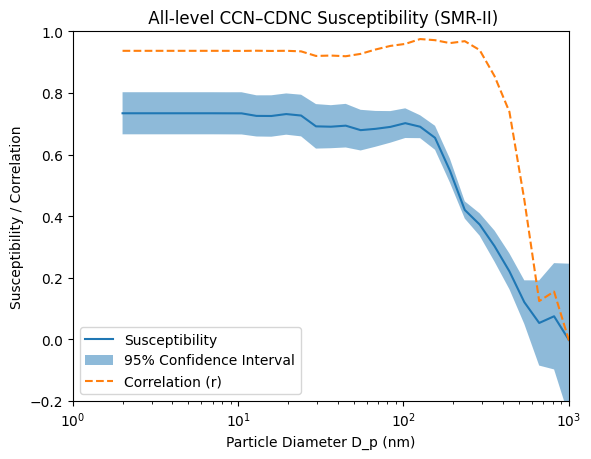

In [11]:
plt.plot(radii*2, reg_ds['slope'].sel(station = 'SMR-II'), label = 'Susceptibility')
plt.fill_between(radii*2,
                 reg_ds['slope'].sel(station = 'SMR-II')-1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 reg_ds['slope'].sel(station = 'SMR-II')+1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(radii*2, reg_ds['r_value'].sel(station = 'SMR-II'), '--', label = 'Correlation (r)')
plt.legend()
plt.title(" All-level CCN–CDNC Susceptibility (SMR-II)")
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0.2, 1])
plt.xlim([1,1000])
plt.xscale('log')

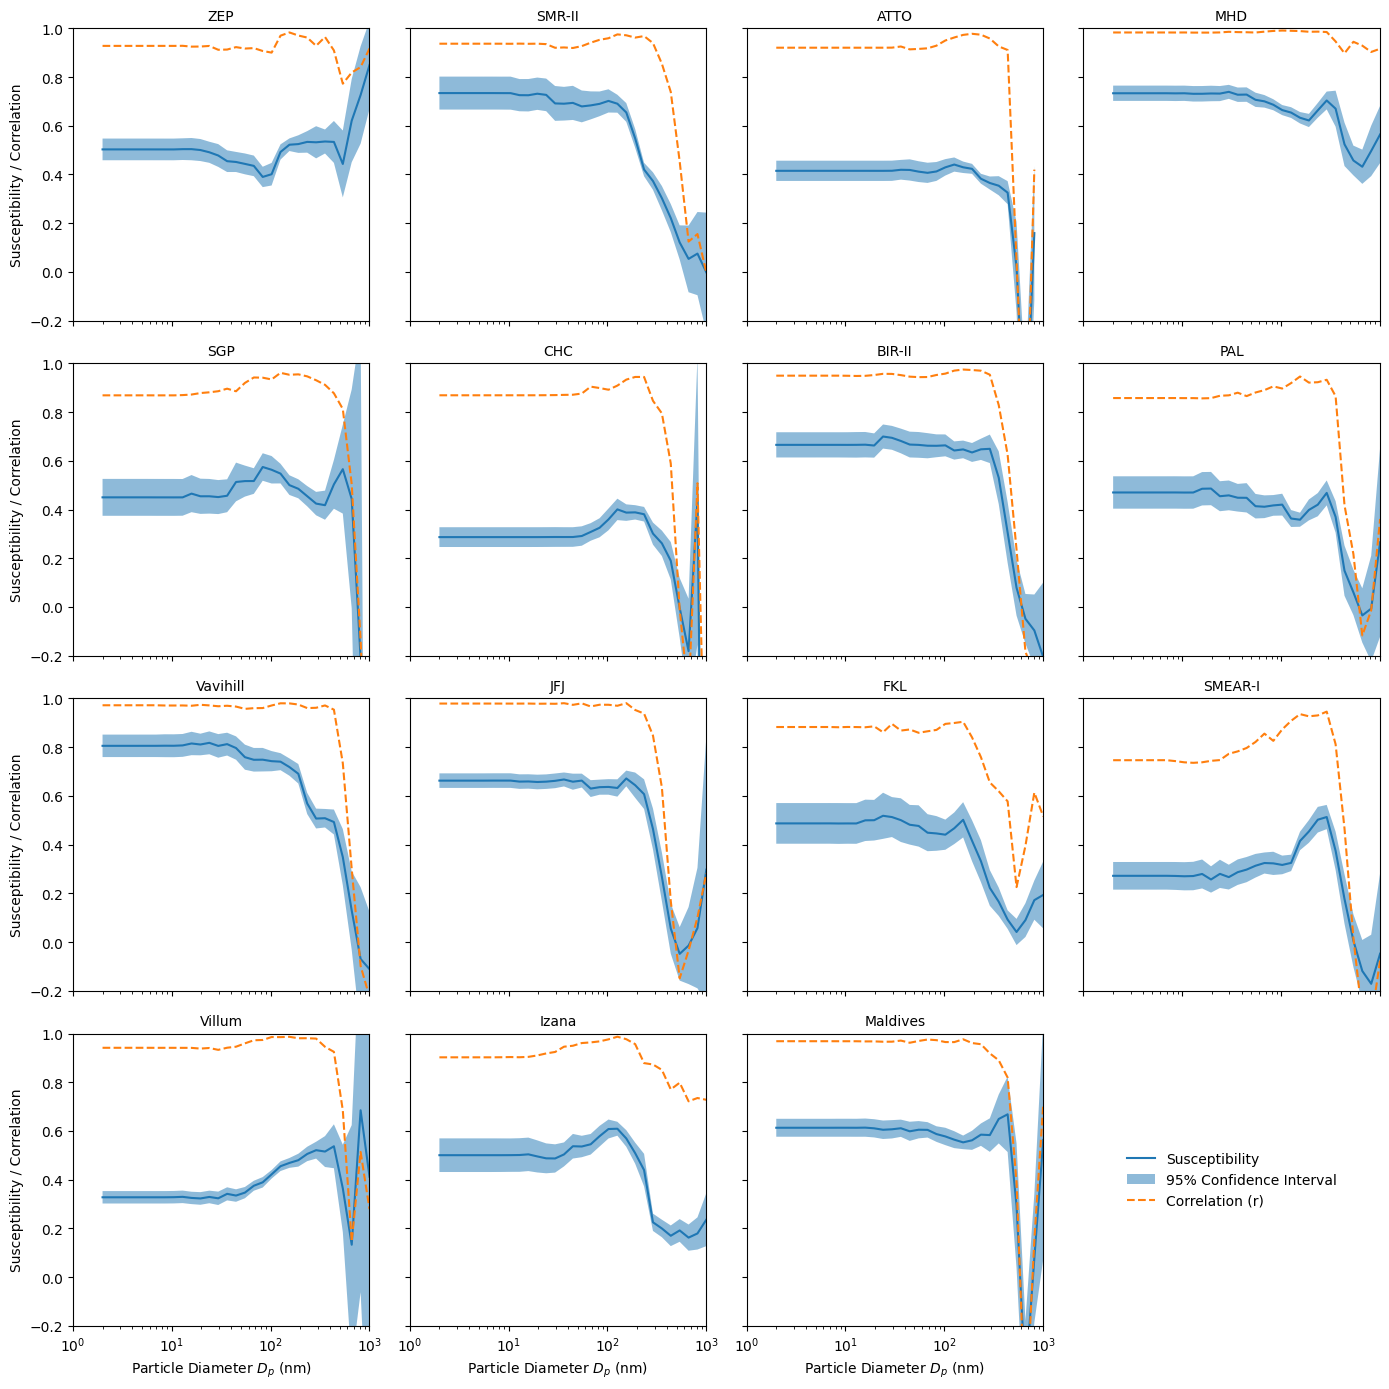

In [12]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)

    ax.plot(radii * 2, slope, label='Susceptibility')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(
        radii * 2,
        r_val,
        '--',
        label='Correlation (r)'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



In [21]:
CCN_all.sel(station = 'SMR-II').isel(radius = 1).to_dataarray()

<xarray.DataArray (variable: 2, time: 8761, lev: 32)> Size: 4MB
array([[[1.43395775e-01, 1.95610245e-01, 5.16054340e-01, ...,
         1.33056056e+03, 1.38966285e+03, 1.42890577e+03],
        [1.44435434e-01, 2.04129832e-01, 5.30630328e-01, ...,
         1.25599539e+03, 1.32422716e+03, 1.35805517e+03],
        [1.42225465e-01, 2.07874971e-01, 5.18784740e-01, ...,
         8.32436593e+02, 9.66764790e+02, 1.02264449e+03],
        ...,
        [1.27265553e-01, 2.60282059e-01, 8.95530568e-01, ...,
         1.52860432e+02, 3.98656067e+02, 3.84984922e+02],
        [1.26926620e-01, 2.80108007e-01, 1.03044890e+00, ...,
         1.81770380e+02, 3.96227797e+02, 3.49101907e+02],
        [1.25786335e-01, 2.93060865e-01, 1.25713626e+00, ...,
         2.61975922e+02, 4.65462706e+02, 3.27958252e+02]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [           nan,            nan,            nan, ...,
                    nan, 1.89284134e+01, 8.90619354e+01],
        [           nan,            nan,            nan, ...,
                    nan, 2.04113503e+01, 8.92994232e+01],
        [           nan,            nan,            nan, ...,
                    nan,            nan, 9.01554794e+01]]],
      shape=(2, 8761, 32))
Coordinates:
  * time      (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
    station   <U8 32B 'SMR-II'
  * lev       (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
    radius    float64 8B 1.23
  * variable  (variable) object 16B 'CCN' 'CDNC'

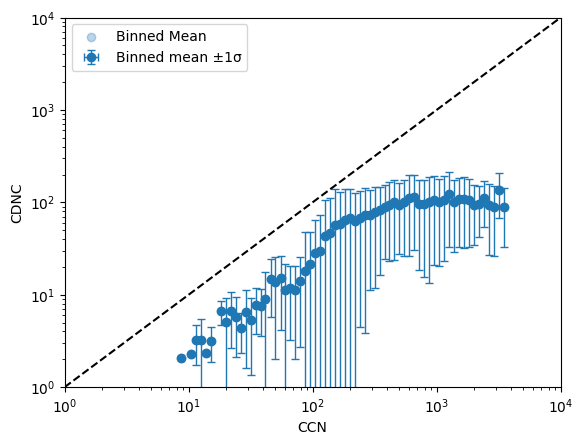

In [34]:
# Binned means
x_mean = CCN_all['CCN'].sel(station='SMR-II').isel(radius=1) \
    .groupby_bins(CCN_all['CCN'].sel(station='SMR-II').isel(radius=1), bins).mean()

y_mean = CCN_all['CDNC'].sel(station='SMR-II') \
    .groupby_bins(CCN_all['CCN'].sel(station='SMR-II').isel(radius=1), bins).mean()

# Binned standard deviations (errors)
x_err = CCN_all['CCN'].sel(station='SMR-II').isel(radius=1) \
    .groupby_bins(CCN_all['CCN'].sel(station='SMR-II').isel(radius=1), bins).std()

y_err = CCN_all['CDNC'].sel(station='SMR-II') \
    .groupby_bins(CCN_all['CCN'].sel(station='SMR-II').isel(radius=1), bins).std()

# Raw data
plt.scatter(
    x_mean,
    y_mean,
    alpha=0.3,
    label='Binned Mean'
)

# Binned means with error bars
plt.errorbar(
    x_mean,
    y_mean,
    xerr=x_err,
    yerr=y_err,
    fmt='o',
    capsize=3,
    elinewidth=1,
    label='Binned mean ±1σ'
)

# Reference & formatting
plt.xscale('log')
plt.yscale('log')
plt.xlim([1, 10000])
plt.ylim([1, 10000])
plt.plot([1, 10000], [1, 10000], 'k--')

plt.xlabel('CCN')
plt.ylabel('CDNC')
plt.legend()
plt.show()


In [31]:
xerr

<xarray.DataArray 'CCN' (CCN_bins: 100)> Size: 800B
array([2.70313846e-02, 3.12635488e-02, 3.45289568e-02, 3.77539294e-02,
       3.82441286e-02, 4.43450697e-02, 4.96412252e-02, 5.27501351e-02,
       5.94312041e-02, 6.11006071e-02, 7.09669499e-02, 7.21765656e-02,
       8.34531523e-02, 9.33145254e-02, 9.70151036e-02, 1.12555429e-01,
       1.20568528e-01, 1.29119147e-01, 1.49655108e-01, 1.61975355e-01,
       1.70764686e-01, 1.93984405e-01, 2.16544809e-01, 2.35096527e-01,
       2.53334640e-01, 2.80259732e-01, 2.95383559e-01, 3.30608047e-01,
       3.64543954e-01, 3.83341521e-01, 4.42294883e-01, 4.67691546e-01,
       5.14561034e-01, 5.75387060e-01, 6.44805769e-01, 6.99062247e-01,
       7.71049209e-01, 8.12832410e-01, 9.15410613e-01, 1.05614824e+00,
       1.08874744e+00, 1.22924392e+00, 1.36660540e+00, 1.46447873e+00,
       1.60858108e+00, 1.76730594e+00, 1.93074680e+00, 2.09213054e+00,
       2.30790579e+00, 2.52551961e+00, 2.78688368e+00, 3.02311569e+00,
       3.31921239e+00, 3.69496847e+00, 4.03020373e+00, 4.40914456e+00,
       4.82009739e+00, 5.27741446e+00, 5.82356226e+00, 6.44025832e+00,
       7.01943676e+00, 7.75285348e+00, 8.50836342e+00, 9.27160414e+00,
       1.01151915e+01, 1.11817547e+01, 1.21402652e+01, 1.34079489e+01,
       1.45860639e+01, 1.58987802e+01, 1.76608141e+01, 1.93299565e+01,
       2.10810456e+01, 2.31778925e+01, 2.50454055e+01, 2.81764262e+01,
       3.00794283e+01, 3.38835864e+01, 3.66195063e+01, 4.04664385e+01,
       4.42610213e+01, 4.79953503e+01, 5.20202173e+01, 5.81083804e+01,
       6.30752544e+01, 7.07134123e+01, 7.41385332e+01, 8.46289862e+01,
       9.16352546e+01, 1.03654095e+02, 1.07885906e+02, 1.19085120e+02,
       1.25822764e+02, 1.52357220e+02, 1.68045033e+02, 1.83143487e+02,
       1.91799727e+02, 2.09378806e+02, 2.28608477e+01,            nan])
Coordinates:
  * CCN_bins  (CCN_bins) object 800B (1.0, 1.096] ... (9120.108, 10000.0]
    station   <U8 32B 'SMR-II'
    radius    float64 8B 1.23